# (Treinamento 2) Atividade vendas no Brasil - Julio Menescal

In [50]:
# importando bibliotecas usadas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [51]:
# importando e lendo o arquivo
df = pd.read_csv('vendas_brasil_1.csv')
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [52]:
# analisando colunas
df.columns

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='object')

## Entregável 1 Numpy

A)

In [53]:
# passando para arrays as colunas

preco_unitario = df["preco_unitario"].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto_pct = df["desconto_pct"].to_numpy()/100
receita_total = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()

In [54]:
# tratando os valores NaN das colunas do dataset

preco_unitario = np.nan_to_num(preco_unitario, nan=0.0)
custo_unitario = np.nan_to_num(custo_unitario, nan=0.0)
quantidade = np.nan_to_num(quantidade, nan=0.0)
desconto_pct = np.nan_to_num(desconto_pct, nan=0.0)
receita_total = np.nan_to_num(receita_total, nan=0.0)
frete = np.nan_to_num(frete, nan=0.0)

B)

In [55]:
# cálculo do valor bruto de cada venda

valor_bruto = preco_unitario*quantidade

In [56]:
# cálculo do valor do desconto

valor_desconto = valor_bruto*desconto_pct

In [57]:
# cálculo do custo total

custo_total = custo_unitario*quantidade

In [58]:
# lucro estimado

lucro = valor_bruto - valor_desconto - custo_total - frete

C)

In [59]:
# mascara de receita acima da média

masc_receita = receita_total > np.mean(receita_total)

# vendo número de casos

print(np.sum(masc_receita))

9236


In [60]:
# mascara de prejuízos

masc_prejuizo = lucro < 0

# vendo número de casos

print(np.sum(masc_prejuizo))

7588


In [61]:
# mascara desconto alto (considerei alto um desconto >= 0.2)

masc_desconto = desconto_pct >= 0.2

# vendo número de casos

print(np.sum(masc_desconto))

7271


In [62]:
# analisando os valores de prejuízos

prejuizos = lucro[masc_prejuizo]
print(prejuizos)

[ -22.3344   -32.43524   -6.38766 ...  -15.76136  -19.67235 -122.135  ]


D)

In [63]:
# receita média

receita_media = np.mean(receita_total)
print(receita_media)

1891.6881729005502


In [64]:
# maior receita

receita_max = np.max(receita_total)
print(receita_max)

58430.28


In [65]:
# menor receita

receita_min = np.min(receita_total)
print(receita_min)

3.7


In [66]:
# lucro médio

lucro_medio = np.mean(lucro)
print(lucro_medio)

313.63955694021325


In [67]:
# quantidade de vendas com prejuízo

qtd_prejuizos = np.sum(masc_prejuizo)
print(qtd_prejuizos)

7588


### Conclusão

In [68]:
# analisando a quantidade percentual de prejuízos

print(qtd_prejuizos/len(quantidade) *100)

20.171730866363614


In [69]:
# analisando margem de lucro

print(lucro_medio/receita_media)

0.16579876188542514


Apesar de apresentar uma porcentagem significativa das vendas com prejuízo (20.17%), a margem de lucro é boa quando comparada com grandes empresas (16.58%).

## Entregável 2 Pandas

A)

In [70]:
# analisando dataset já importado no início

df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [72]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [73]:
df.shape

(37617, 21)

In [74]:
df.isna().sum()

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


Respostas:
1) Há 37617 linhas e 21 colunas
2) Existem dados faltantes nas colunas: canal_venda (50), vendedor (40), margem_pct (82), frete (1879), avaliacao_cliente (2955) e prazo_entrega_dias (1504)
3) Colunas numéricas: mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias
4) Colunas categóricas: todas as outras

B)

In [75]:
# converter data para datetime

df["data_venda"] = pd.to_datetime(df["data_venda"], format="mixed", dayfirst=True)

In [76]:
# padronização de coluna "canal_venda"

analise = df["canal_venda"].unique()
print(f"Inicialmente: {analise}")

df["canal_venda"] = df["canal_venda"].replace({
    "APP Mobile": "App Mobile",
    "App mobile": "App Mobile",
    "app mobile": "App Mobile",

    "Site web": "Site Web",
    "site web": "Site Web",
    "SiteWeb": "Site Web",

    "Loja Fisica": "Loja Física",
    "Loja fisica": "Loja Física",
    "loja física": "Loja Física"
})

print(f"Após padronização: {df['canal_venda'].unique()}")

Inicialmente: ['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas'
 'APP Mobile' 'site web' 'Site web' 'app mobile' 'SiteWeb' nan
 'Loja Fisica' 'App mobile' 'loja física' 'Loja fisica']
Após padronização: ['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas' nan]


In [77]:
# tratando NaN em "canal_venda"

df["canal_venda"] = df["canal_venda"].fillna("Desconhecido")

# tratando NaN em "frete"

df["frete"] = df["frete"].fillna(0)

# tratando NaN em "avaliacao_cliente"

mediana = df["avaliacao_cliente"].median()
df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna(mediana)

# tratando NaN em "prazo_entrega_dias"

media = df["prazo_entrega_dias"].mean()
df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(media)

Justificativas: escolhi essas colunas para tratar os valores nulos, pois "canal_venda" eu já havia escolhido para padronizar, "frete", "avaliacao_cliente" e "prazo_entrega_dias" foram as colunas com mais valores nulos.
"frete" substitui NaN por valores nulos pois evita possíveis erros no cálculo do lucro.
"avaliacao_cliete" substitui pela mediana pois é menos influenciada por valores extremos.
"prazo_entrega_dias" aqui substitui pela média, pois é importante a influência dos extremos na estimativa da entrega.

C)

In [78]:
# nova coluna "ano"

df["ano"] = df["data_venda"].dt.year

In [79]:
# nova coluna "lucro_total"
valor_bruto = df["preco_unitario"]*df["quantidade"]
valor_desconto = valor_bruto*(df["desconto_pct"]/100)
custo_total = df["custo_unitario"]*df["quantidade"]
df["lucro_total"] = (valor_bruto - valor_desconto - custo_total - df["frete"])

In [80]:
# nova coluna faixas de receita (usando apply)

# análise da faixa

print(np.mean(df["receita_total"]), np.median(df["receita_total"]))

#implementação

def faixa(x):
  if x < 600:
    return "Baixa"
  elif x < 1900:
    return "Média"
  else:
    return "Alta"

df["faixa_receita"] = df["receita_total"].apply(faixa)

1891.6881729005502 789.57


D)

In [81]:
# filtro de receitas acima da média

receita_acima_media = df[df["receita_total"] > np.mean(df["receita_total"])]

print(f"{(len(receita_acima_media)/len(receita_total)*100):.3f}%")

24.553%


Veja que quase 1/4 das receitas foram acima da média, o que não é um mal resultado, mas há margem de melhoria.

In [82]:
# filtro "canal_venda"

tipo_venda = df[df["canal_venda"] == "Loja Física"]

print(f"{(len(tipo_venda)/len(df["canal_venda"])*100):.3f}%")

19.932%


19.932% das vendas foram por meio de Lojas Físicas, mostrando ainda a importância desses estabelecimentos.

In [83]:
# filtro "devolucao"

devolucao = df[df["devolucao"] == True]

print(f"{(len(devolucao)/len(df["devolucao"])*100):.3f}%")

9.389%


Menos de 10% dos compradores devolveram suas compras, o que mostra uma boa taxa de satisfação.

E)

In [84]:
# agrupando a receita total de cada categoria

df.groupby("categoria")["receita_total"].sum()

,receita_total
categoria,
Alimentação,3331601.51
Eletrônicos,45017479.88
Esportes,11567480.75
Livros,4462597.93
Vestuário,6780473.93


Veja que a Categoria de maior Receita Total foi "Eletrônicos".

In [85]:
# agrupando canais de acordo com a quantidade de vendas totais

df.groupby("canal_venda")["canal_venda"].count()

,canal_venda
canal_venda,
App Mobile,11258
Desconhecido,50
Loja Física,7498
Marketplace,5604
Site Web,11346
Televendas,1861


App Mobile e Site Web dominaram as vendas, sendo canais muito mais usados que os outros.

In [86]:
# agrupando a média de lucro de cada categoria

df.groupby("categoria")["lucro_total"].mean()

,lucro_total
categoria,
Alimentação,51.688080
Eletrônicos,1054.863053
Esportes,243.932871
Livros,81.411493
Vestuário,134.154895


A categoria mais lucrativa, em média, foi "Eletrônicos".

F)

In [87]:
# criando uma tabela manualmente

regioes = pd.DataFrame({
    "cidade":[
        "Rio de Janeiro",
        "São Paulo",
        "Curitiba",
        "Salvador"
    ],
    "regiao":[
        "Sudeste",
        "Sudeste",
        "Sul",
        "Nordeste"
    ]
})

In [88]:
# juntando informações da tabela criada com o dataset

df_criado = df.merge(regioes,on="cidade",how="left")

In [89]:
df_criado.groupby("regiao")["quantidade"].sum()

,quantidade
regiao,
Nordeste,27533
Sudeste,54637
Sul,28612


Veja que agora é possível analisar informações por regiões do Brasil, como no exemplo a quantidade de vendas em cada região, predominando no Sudeste.

### Conclusão

Após o tratamento e padronização do dataset, foi possível fazer análises mais conclusivas sobre seus valores. As métricas criadas como "lucro_total" enriqueceram as análises e permmitiram compreender melhor o desempenho dessas vendas: a categoria "Eletrônicos" se destagou significativamente, sendo a de maior receita e os canais de venda digital (App Mobile e Site Web) são os com maior volume de venda, mas ainda uma parcela considerável compra em lojas físicas (cerca de 20%), além disso há uma alta taxa de satisfação dos clientes (menos de 10% de devolução)e a Região de maior volume de vendas é a Sudeste.

## Entregável 3 Seaborn

A)

In [90]:
# agrupando receitas por categoria

receita_categoria = (df.groupby("categoria")["receita_total"].sum()).sort_values(ascending=False)

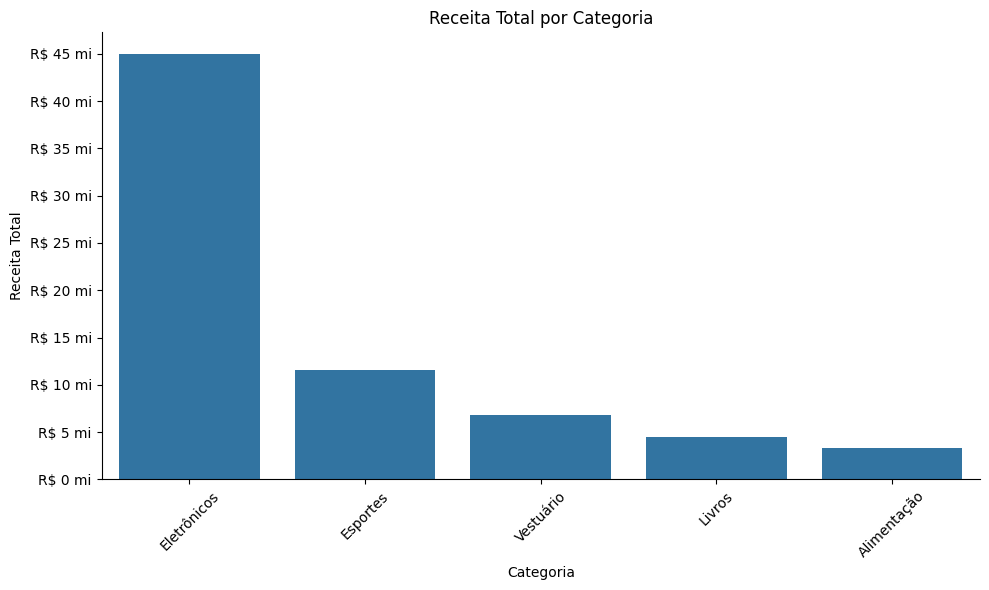

In [91]:
# plotando o gráfico de barras

plt.figure(figsize=(10,6))
ax = sns.barplot(x=receita_categoria.index, y=receita_categoria.values)

plt.xlabel("Categoria")
plt.ylabel("Receita Total")
plt.title("Receita Total por Categoria")
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.0f} mi")
)

ax.yaxis.set_major_locator(
    ticker.MultipleLocator(5_000_000)
)

sns.despine()
plt.tight_layout()
plt.show()

B)

In [92]:
# relacionando os dados

receita_mensal = (df.set_index("data_venda").resample("ME")["receita_total"].sum())

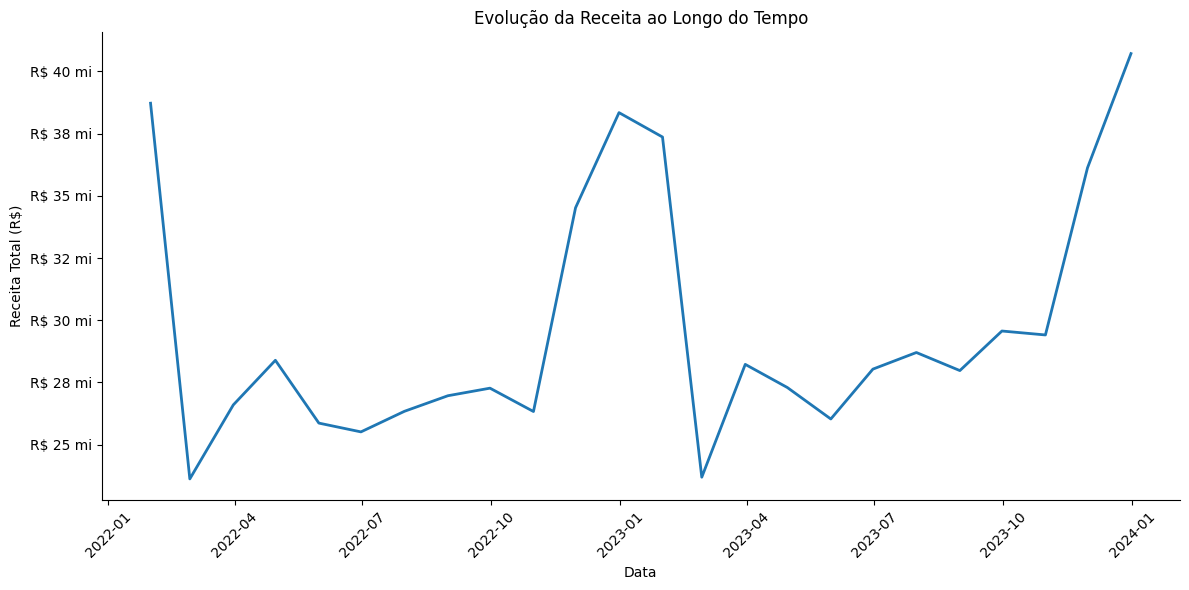

In [101]:
# plotando o gráfico de linha

plt.figure(figsize=(12, 6))

ax = sns.lineplot(x=receita_mensal.index, y=receita_mensal.values, linewidth=2)

plt.title("Evolução da Receita ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Receita Total (R$)")
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"R$ {x/1_000_00:.0f} mi")
)

ax.yaxis.set_major_locator(
    ticker.MultipleLocator(250_000)
)

sns.despine()
plt.tight_layout()
plt.show()

C)

In [106]:
# definindo amostra

amostra = df.sample(n=1000, random_state=42)

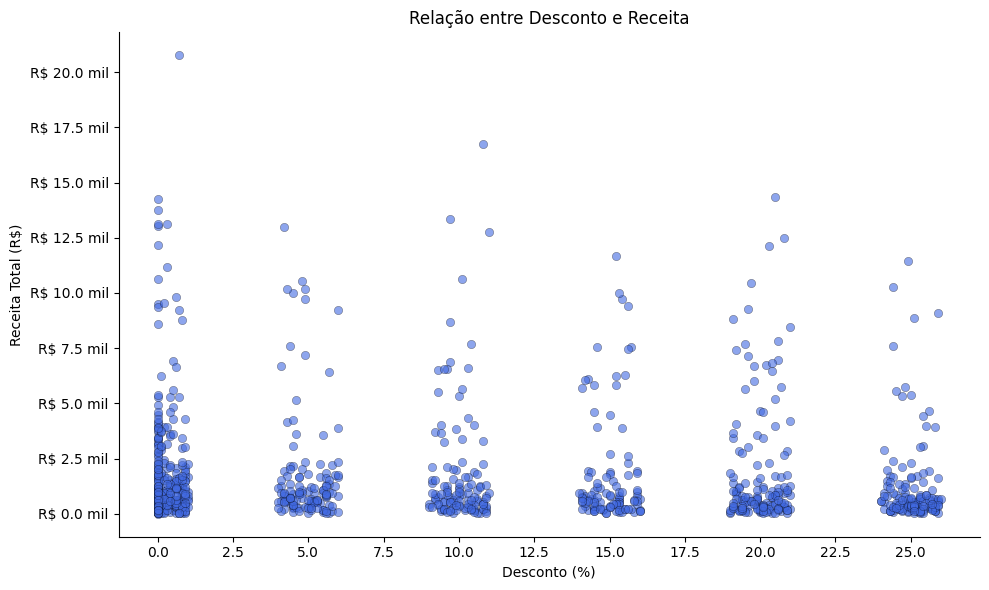

In [120]:
# plotando o gráfico de dispersão

plt.figure(figsize=(10, 6))

ax= sns.scatterplot(
    data=amostra,
    x="desconto_pct",
    y="receita_total",
    alpha=0.6,
    color="royalblue",
    edgecolor="black",
    linewidth=0.3
)

plt.title("Relação entre Desconto e Receita")
plt.xlabel("Desconto (%)")
plt.ylabel("Receita Total (R$)")

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"R$ {x/1_000:.1f} mil")
)

# Marcações no eixo Y a cada R$ 250 mil
ax.yaxis.set_major_locator(
    ticker.MultipleLocator(2500)
)

# Marcações no eixo X a cada 2,5%
ax.xaxis.set_major_locator(
    ticker.MultipleLocator(2.5)
)

sns.despine()
plt.tight_layout()
plt.show()


D)

In [116]:
# colunas relevantes

colunas_numericas = df[[
    "preco_unitario",
    "custo_unitario",
    "quantidade",
    "desconto_pct",
    "receita_total",
    "frete",
    "lucro_total"
]]

In [117]:
# calculando a corelação

correlacao = colunas_numericas.corr()

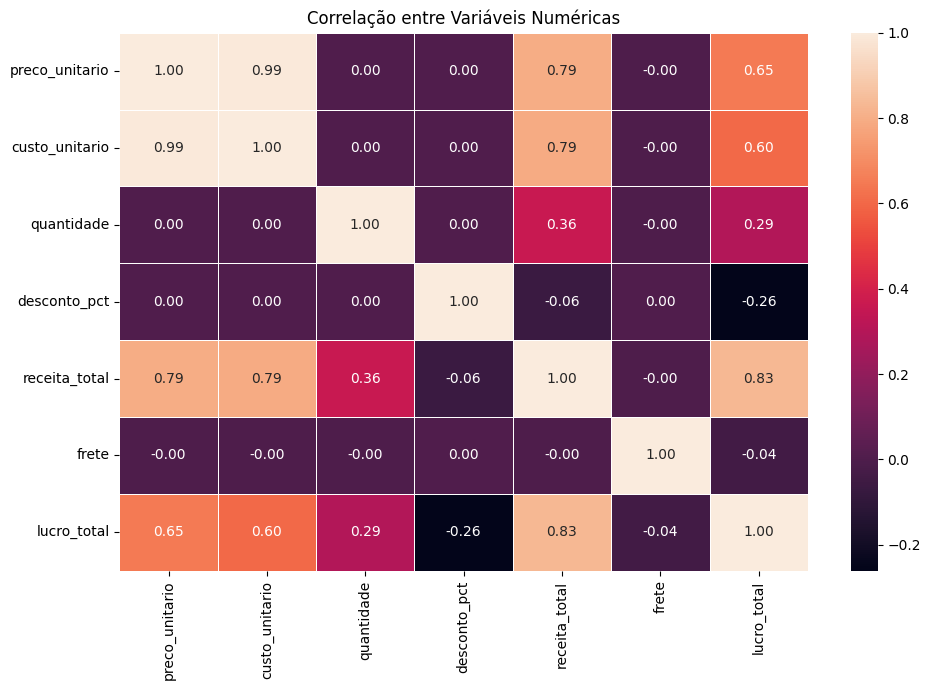

In [118]:
# plotando o gráfico heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()

### Conclusão

Após a análise dos gráficos foi possível identificaar padrões importantes no comportamento das vendas. No gráfico de barras é possível concluir que a categoria "Eletônicos" apresentou uma receita significativamente superior às demais, enquanto no gráfico de linha é possível ver que, ao longo do tempo, a receita mensal demonstrou oscilações consideráveis, sem uma tendência contínua, embora o período termine com uma forte alta. O gráfico de dispersão é inconcluisvo, uma vez que não indica uma relação clara entre crescimento da receita e aumento do desconto, por último, a análise de correlação mostra que a receita total possui forte relação positiva com o lucro, enquanto o desconto apresenta uma relção moderada com o mesmo. Assim, os gráficos mostram a importância dos "Eletrônicos", enquanto deve haver uma preocupação com os altos descontos para não cair os lucros.